In [3]:
from pathlib import Path
import gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Intramolecular Noncovalent"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783

REUSE_EXISTING_MOLECULE_FILE = True
SAVE_EVERY = 20

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run from GSCDB root folder or from GSCDB/Analysis.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mol_log = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"
rxn_out = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
val_out = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
err_out = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)

# ============================================================
# HELPERS
# ============================================================
def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem_state(qf):
    charge, spin = 0, 1
    if not qf.exists():
        return charge, spin

    lines = qf.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, spin = int(float(p[0])), int(float(p[1]))
            break
    return charge, spin

def prepare_atoms(mol):
    xf, qf = X / f"{mol}.xyz", Q / f"{mol}.in"
    charge, spin = read_qchem_state(qf)
    atoms = read(xf)

    charge = int(float(atoms.info.get("charge", charge)))
    spin = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", spin))))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin
    atoms.info["external_field"] = np.array([0.0, 0.0, 0.0], dtype=float)

    return atoms, charge, spin

def mols_from_stoich(st):
    return [p.strip() for p in str(st).split(",")][1::2]

def reaction_energy_kcal(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e_ev = 0.0

    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, col])

    return e_ev * EV_TO_KCAL

def pooled_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x, y = d["x"].to_numpy(float), d["y"].to_numpy(float)
    e = y - x

    return {
        "N_points": len(x),
        "MAE": np.mean(np.abs(e)) if len(x) else np.nan,
        "RMSE": np.sqrt(np.mean(e ** 2)) if len(x) else np.nan,
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

# ============================================================
# LOAD BASE FILES
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = pd.read_csv(I / "Datasets.csv", index_col=0)
df_rxn_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

datatype_datasets = df_info.index[df_info["Datatype"] == DATATYPE].tolist()
ev = df_eval[df_eval["Dataset"].isin(datatype_datasets)].copy()

rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()

print("\nDatasets in this Datatype:")
print(datatype_datasets)
print("Number of datasets:", len(datatype_datasets))
print("Number of data points:", len(ev))

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})
print("Unique molecules:", len(all_mols))

# ============================================================
# MOLECULE TABLE
# ============================================================
if mol_out.exists() and REUSE_EXISTING_MOLECULE_FILE:
    df_mol = pd.read_csv(mol_out, index_col=0)
    print("\nReusing existing molecule-energy file:")
    print(mol_out)
else:
    rows, missing_xyz = [], []

    for mol in all_mols:
        if not (X / f"{mol}.xyz").exists():
            missing_xyz.append(mol)
            continue

        atoms, charge, spin = prepare_atoms(mol)
        rows.append({
            "Molecule": mol,
            "charge": charge,
            "spin": spin,
            "num_atoms": len(atoms),
        })

    if missing_xyz:
        print("First missing xyz files:", missing_xyz[:20])
        raise FileNotFoundError(f"{len(missing_xyz)} xyz files are missing.")

    df_mol = pd.DataFrame(rows).set_index("Molecule")

for col in MODELS:
    if col not in df_mol.columns:
        df_mol[col] = np.nan

# ============================================================
# MACE-POLAR MOLECULAR ENERGIES
# ============================================================
errors = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)

    for n, mol in enumerate(tqdm(all_mols, desc=col), start=1):
        if REUSE_EXISTING_MOLECULE_FILE and pd.notna(df_mol.loc[mol, col]):
            continue

        try:
            atoms, charge, spin = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc

            df_mol.loc[mol, "charge"] = charge
            df_mol.loc[mol, "spin"] = spin
            df_mol.loc[mol, "num_atoms"] = len(atoms)
            df_mol.loc[mol, col] = float(atoms.get_potential_energy())

        except Exception as exc:
            df_mol.loc[mol, col] = np.nan
            errors.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % SAVE_EVERY == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(mol_log, index=False)
df_mol.to_csv(mol_out)

print("\nMolecule-energy missing values:")
print(df_mol[list(MODELS)].isna().sum())

# ============================================================
# REACTION ENERGIES
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = reaction_energy_kcal(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy check:")
for col in MODELS:
    print(
        col,
        "| NaN:", df_rxn[col].isna().sum(),
        "| exact zeros:", np.isclose(df_rxn[col].fillna(np.nan), 0.0, equal_nan=False).sum(),
        "| unique:", df_rxn[col].nunique(),
    )

# ============================================================
# RESULTS VALUES AND ERRORS
# ============================================================
df_val = val_base.copy()
for col in MODELS:
    df_val[col] = df_rxn[col]

df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")

df_err.to_csv(err_out)

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC ERROR, NER/MRE
# For Intramolecular Noncovalent, analyze.ipynb default metric = MAE.
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]

mae_rows, rmse_rows, metric_rows, long_rows = [], [], [], []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    std_metric = float(df_std.loc[dataset, "Metric"])

    mae_row = {"Dataset": dataset, "Datatype": DATATYPE}
    rmse_row = {"Dataset": dataset, "Datatype": DATATYPE}
    metric_row = {"Dataset": dataset, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g_err[col], errors="coerce")
        complete = err.notna().all()
        n_total = len(err)
        n_used = int(err.notna().sum())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric_error = mae
            ner = metric_error / std_metric
            status = "COMPLETE"
        else:
            mae = rmse = metric_error = ner = np.nan
            status = "INCOMPLETE"

        mae_row[col] = mae
        rmse_row[col] = rmse
        metric_row[col] = metric_error

        long_rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": col,
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric_error,
            "Standard_Error_Metric": std_metric,
            "NER": ner,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)

df_rel = df_metric.copy()
for col in EVAL_COLS:
    df_rel[col] = df_metric[col] / df_std.loc[df_metric.index, "Metric"]

df_rel.to_csv(rel_out)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary_rows = []

for col in EVAL_COLS:
    pm = pooled_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"] == col]

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": pm["N_points"],
        "N_datasets_total": len(sub),
        "N_datasets_complete": int((sub["Status"] == "COMPLETE").sum()),
        "N_datasets_incomplete": int((sub["Status"] == "INCOMPLETE").sum()),
        "Pooled_MAE": pm["MAE"],
        "Pooled_RMSE": pm["RMSE"],
        "Pearson_r": pm["Pearson_r"],
        "Mean_Set_MAE": sub["MAE"].mean(skipna=True),
        "Mean_Set_RMSE": sub["RMSE"].mean(skipna=True),
        "Mean_Relative_Error_NER": sub["NER"].mean(skipna=True),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_out, index=False)

long_out = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"
df_long.to_csv(long_out, index=False)

print("\nDatatype summary:")
print(df_summary.to_string(index=False))

# ============================================================
# CHECK wB97M-V AGAINST EXISTING Statistical_errors.csv
# ============================================================
stat_file = A / "Statistical_errors.csv"
row_name = f"Mean {DATATYPE}"

if stat_file.exists():
    df_stat = pd.read_csv(stat_file, index_col=0)

    if row_name in df_stat.index and "wB97M-V" in df_stat.columns:
        our = df_summary.loc[df_summary["Model"] == "wB97M-V", "Mean_Relative_Error_NER"].iloc[0]
        old = df_stat.loc[row_name, "wB97M-V"]

        print("\nComparison with existing Statistical_errors.csv:")
        print("Row:", row_name)
        print(f"Our calculated wB97M-V MRE/NER : {our:.10f}")
        print(f"Statistical_errors.csv value   : {old:.10f}")
        print(f"Absolute difference            : {abs(our - old):.3e}")
    else:
        print("\nStatistical_errors.csv found, but required row/column was missing.")
else:
    print("\nNo Analysis/Statistical_errors.csv found. Skipped comparison.")

print("\nSaved files:")
for f in [mol_out, mol_log, rxn_out, val_out, err_out, mae_out, rmse_out, metric_out, rel_out, long_out, summary_out]:
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cuda
DATATYPE: Intramolecular Noncovalent

Datasets in this Datatype:
['ACONF', 'Amino20x4', 'BUT14DIOL', 'ICONF', 'IDISP', 'MCONF', 'PCONF21', 'Pentane13', 'SCONF', 'UPU23']
Number of datasets: 10
Number of data points: 304
Unique molecules: 353

Reusing existing molecule-energy file:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Molecule_Energies_MACE_POLAR_Datatype_Intramolecular_Noncovalent_ALL3.csv

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


mace-polar-1-s: 100%|██████████| 353/353 [00:00<00:00, 109575.88it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


mace-polar-1-m: 100%|██████████| 353/353 [00:00<00:00, 112438.43it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 353/353 [00:00<00:00, 116070.03it/s]



Molecule-energy missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Reaction energies: 100%|██████████| 304/304 [00:00<00:00, 2759.37it/s]


Reaction-energy check:
mace-polar-1-s | NaN: 0 | exact zeros: 0 | unique: 304
mace-polar-1-m | NaN: 0 | exact zeros: 0 | unique: 304
mace-polar-1-l | NaN: 0 | exact zeros: 0 | unique: 304

Datatype summary:
                  Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Intramolecular Noncovalent        wB97M-V kcal/mol       304                10                   10                      0    0.237732     0.503304   0.994207      0.366288       0.531988                 1.070761
Intramolecular Noncovalent mace-polar-1-s kcal/mol       304                10                   10                      0    0.581256     0.876930   0.980842      0.713126       0.923715                 2.991526
Intramolecular Noncovalent mace-polar-1-m kcal/mol       304                10                   10                      0    0.317681     0.682874   0.9

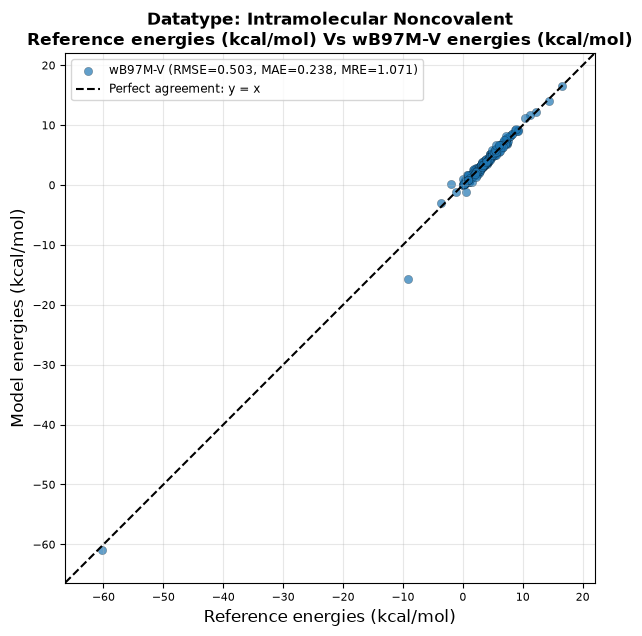

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_Reference_vs_wB97M-V_RMSE_MAE_MRE.png


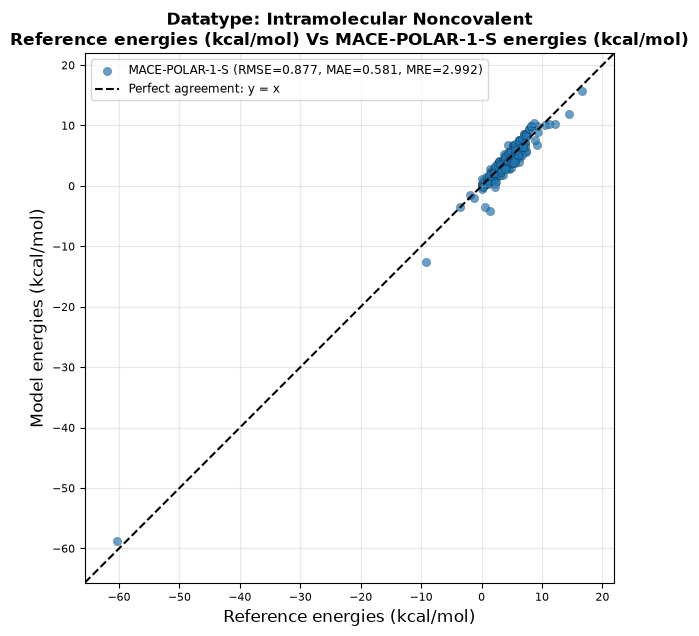

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_Reference_vs_mace-polar-1-s_RMSE_MAE_MRE.png


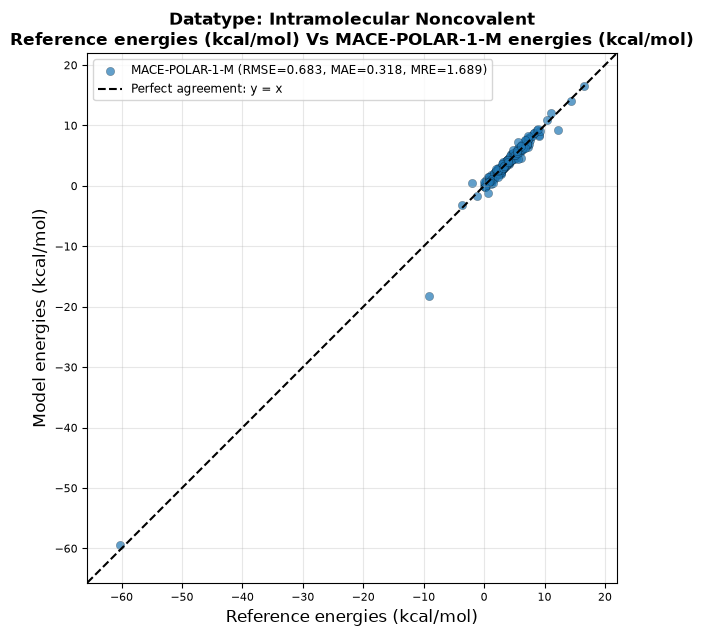

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_Reference_vs_mace-polar-1-m_RMSE_MAE_MRE.png


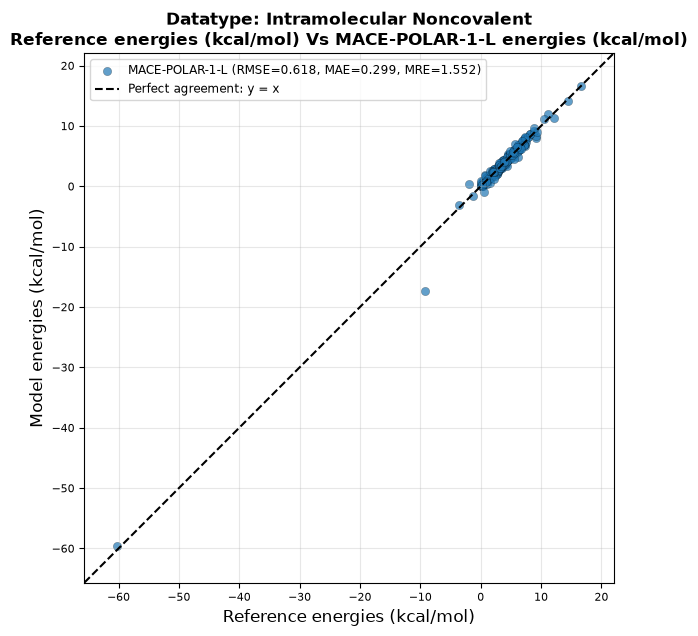

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_Reference_vs_mace-polar-1-l_RMSE_MAE_MRE.png


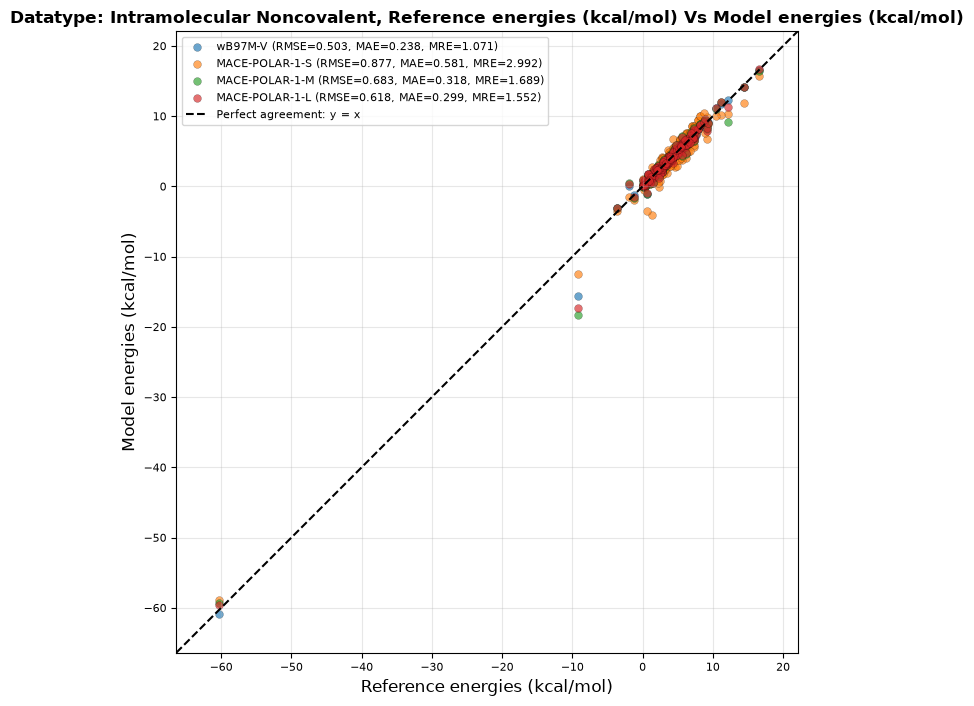

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_all_models_RMSE_MAE_MRE.png


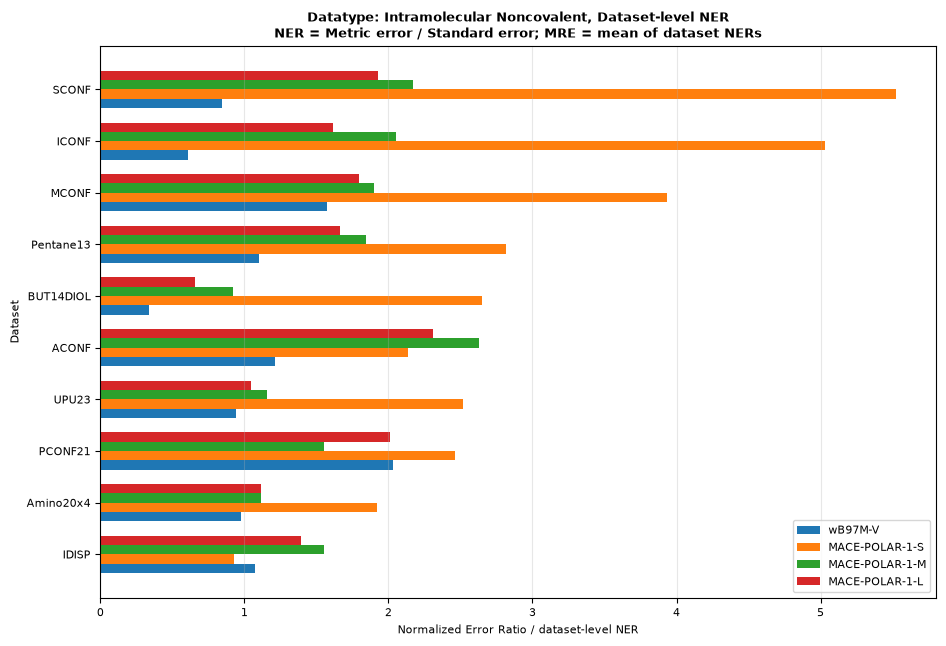

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Intramolecular_Noncovalent_dataset_level_NER_all_models.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Intramolecular_Noncovalent_correlation_plot_metrics_RMSE_MAE_MRE.csv

Plot metrics:
                  Datatype          Model     Unit   N     RMSE      MAE  Mean_Relative_Error_NER  Pearson_r
Intramolecular Noncovalent        wB97M-V kcal/mol 304 0.503304 0.237732                 1.070761   0.994207
Intramolecular Noncovalent MACE-POLAR-1-S kcal/mol 304 0.876930 0.581256                 2.991526   0.980842
Intramolecular Noncovalent MACE-POLAR-1-M kcal/mol 304 0.682874 0.317681                 1.689168   0.988628
Intramolecular Noncovalent MACE-POLAR-1-L kcal/mol 304 0.618462 0.298506                 1.552490   0.990688


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PLOTS FOR DATATYPE: Intramolecular Noncovalent
# ============================================================
DATATYPE = "Intramolecular Noncovalent"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
summary_file = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"
per_set_file = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"

df = pd.read_csv(val_file, index_col=0)
summary = pd.read_csv(summary_file)
per_set = pd.read_csv(per_set_file)

def point_metrics(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAE": np.mean(np.abs(e)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def get_mre(model):
    return float(summary.loc[summary["Model"] == model, "Mean_Relative_Error_NER"].iloc[0])

def lim(*series):
    values = np.concatenate([
        pd.to_numeric(s, errors="coerce").dropna().to_numpy(float)
        for s in series
    ])

    pad = 0.07 * (values.max() - values.min())
    return values.min() - pad, values.max() + pad

plot_rows = []

# ============================================================
# 1. Individual correlation plots
# ============================================================
for model in MODELS:
    m = point_metrics(df["Reference"], df[model])
    mre = get_mre(model)

    plot_rows.append({
        "Datatype": DATATYPE,
        "Model": LABELS[model],
        "Unit": UNIT,
        "N": m["N"],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "Mean_Relative_Error_NER": mre,
        "Pearson_r": m["Pearson_r"],
    })

    lo, hi = lim(df["Reference"], df[model])

    plt.figure(figsize=(7.0, 6.4))

    plt.scatter(
        df["Reference"],
        df[model],
        s=36,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.20,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference energies (kcal/mol)", fontsize=12)
    plt.ylabel("Model energies (kcal/mol)", fontsize=12)

    plt.title(
        f"Datatype: {DATATYPE}\n"
        f"Reference energies (kcal/mol) Vs {LABELS[model]} energies (kcal/mol)",
        fontsize=12,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=8.5)
    plt.tight_layout()

    out = FIG / f"{TAG}_Reference_vs_{model}_RMSE_MAE_MRE.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

# ============================================================
# 2. Combined all-model correlation plot
# ============================================================
lo, hi = lim(df["Reference"], *[df[m] for m in MODELS])

plt.figure(figsize=(7.7, 7.1))

for model in MODELS:
    m = point_metrics(df["Reference"], df[model])
    mre = get_mre(model)

    plt.scatter(
        df["Reference"],
        df[model],
        s=32,
        alpha=0.66,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference energies (kcal/mol)", fontsize=12)
plt.ylabel("Model energies (kcal/mol)", fontsize=12)

plt.title(
    "Datatype: Intramolecular Noncovalent, "
    "Reference energies (kcal/mol) Vs Model energies (kcal/mol)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=7.8)
plt.tight_layout()

out = FIG / f"{TAG}_all_models_RMSE_MAE_MRE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

# ============================================================
# 3. Dataset-level NER bar plot
# ============================================================
ner = per_set.pivot(index="Dataset", columns="Model", values="NER")
ner = ner[MODELS]

ordered = ner.loc[ner[["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]].max(axis=1).sort_values().index]

plt.figure(figsize=(9.5, max(6.5, 0.35 * len(ordered))))

y = np.arange(len(ordered))
bar_h = 0.18

for i, model in enumerate(MODELS):
    plt.barh(
        y + (i - 1.5) * bar_h,
        ordered[model],
        height=bar_h,
        label=LABELS[model],
    )

plt.yticks(y, ordered.index)
plt.xlabel("Normalized Error Ratio / dataset-level NER")
plt.ylabel("Dataset")
plt.title(
    "Datatype: Intramolecular Noncovalent, Dataset-level NER\n"
    "NER = Metric error / Standard error; MRE = mean of dataset NERs",
    fontweight="bold",
)

plt.grid(axis="x", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

out = FIG / f"{TAG}_dataset_level_NER_all_models.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

plot_metrics = pd.DataFrame(plot_rows)
plot_metrics_out = A / f"{TAG}_correlation_plot_metrics_RMSE_MAE_MRE.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)

print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))